# Mushroom Classification using Naive Bayes

## 1. Project Overview

### Problem Statement

The goal of this project is to build a Machine Learning model
that predicts whether a mushroom is edible or poisonous based
on its physical characteristics.

### Machine Learning Problem

This is a Supervised Learning problem.

The target variable represents whether the mushroom is edible
or poisonous, so this is a Binary Classification problem.

### Objective

Build an end-to-end Machine Learning solution that:

- Understands and analyzes the dataset.
- Performs data cleaning and preprocessing.
- Applies Naive Bayes.
- Evaluates the model using appropriate classification metrics.
- Performs error analysis.
- Explores the assumptions behind Naive Bayes.
- Saves the trained model pipeline.
- Deploys the model using Streamlit.

In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "uciml/mushroom-classification"
)

print("Dataset path:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 445kB/s]

Extracting files...
Dataset path: C:\Users\Abdel\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


In [77]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import os

dataset_path = r"C:\Users\Abdel\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1"

print(os.listdir(dataset_path))

['mushrooms.csv']


In [3]:
import shutil
import os

source_path = os.path.join(
    dataset_path,
    "mushrooms.csv"
)

destination_path = r"C:\PROJECT\ML_PROJECT\Mushroom-classification-project\data\raw\mushrooms.csv"

shutil.copy2(source_path, destination_path)

print("Dataset copied successfully.")

Dataset copied successfully.


In [4]:
import os

print(os.path.exists(destination_path))

True


In [5]:
import pandas as pd

df = pd.read_csv(destination_path)

print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [6]:
print(df.columns.tolist())

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [8]:
missing_values = (df == "?").sum()

print(missing_values[missing_values > 0])

stalk-root    2480
dtype: int64


In [9]:
print(df["class"].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


In [10]:
print(df["class"].value_counts(normalize=True) * 100)

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [11]:
df["stalk-root"] = df["stalk-root"].replace("?", ...)

In [12]:
print(df["stalk-root"].value_counts())

stalk-root
b           3776
Ellipsis    2480
e           1120
c            556
r            192
Name: count, dtype: int64


In [13]:
print(
    pd.crosstab(
        df["stalk-root"],
        df["class"],
        normalize="index"
    ) * 100
)

class                e          p
stalk-root                       
Ellipsis     29.032258  70.967742
b            50.847458  49.152542
c            92.086331   7.913669
e            77.142857  22.857143
r           100.000000   0.000000


In [14]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].value_counts())


class
class
e    4208
p    3916
Name: count, dtype: int64

cap-shape
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

cap-surface
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

cap-color
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

bruises
bruises
f    4748
t    3376
Name: count, dtype: int64

odor
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

gill-attachment
gill-attachment
f    7914
a     210
Name: count, dtype: int64

gill-spacing
gill-spacing
c    6812
w    1312
Name: count, dtype: int64

gill-size
gill-size
b    5612
n    2512
Name: count, dtype: int64

gill-color
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64

stalk-shape
stalk

In [15]:
id="n2y4xk"
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

class: 2 unique values
cap-shape: 6 unique values
cap-surface: 4 unique values
cap-color: 10 unique values
bruises: 2 unique values
odor: 9 unique values
gill-attachment: 2 unique values
gill-spacing: 2 unique values
gill-size: 2 unique values
gill-color: 12 unique values
stalk-shape: 2 unique values
stalk-root: 5 unique values
stalk-surface-above-ring: 4 unique values
stalk-surface-below-ring: 4 unique values
stalk-color-above-ring: 9 unique values
stalk-color-below-ring: 9 unique values
veil-type: 1 unique values
veil-color: 4 unique values
ring-number: 3 unique values
ring-type: 5 unique values
spore-print-color: 9 unique values
population: 6 unique values
habitat: 7 unique values


In [16]:
id="z6j3sa"
unique_counts = df.nunique().sort_values()

print(unique_counts)

veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-above-ring     4
veil-color                   4
cap-surface                  4
stalk-surface-below-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


In [17]:
categorical_features = df.drop(columns="class").columns

for column in categorical_features:
    print(f"\n===== {column} =====")
    
    result = pd.crosstab(
        df[column],
        df["class"],
        normalize="index"
    ) * 100
    
    print(result.round(2))


===== cap-shape =====
class           e       p
cap-shape                
b           89.38   10.62
c            0.00  100.00
f           50.63   49.37
k           27.54   72.46
s          100.00    0.00
x           53.28   46.72

===== cap-surface =====
class            e       p
cap-surface               
f            67.24   32.76
g             0.00  100.00
s            44.76   55.24
y            46.36   53.64

===== cap-color =====
class           e      p
cap-color               
b           28.57  71.43
c           72.73  27.27
e           41.60  58.40
g           56.09  43.91
n           55.34  44.66
p           38.89  61.11
r          100.00   0.00
u          100.00   0.00
w           69.23  30.77
y           37.31  62.69

===== bruises =====
class        e      p
bruises              
f        30.67  69.33
t        81.52  18.48

===== odor =====
class      e      p
odor               
a      100.0    0.0
c        0.0  100.0
f        0.0  100.0
l      100.0    0.0
m        0.0

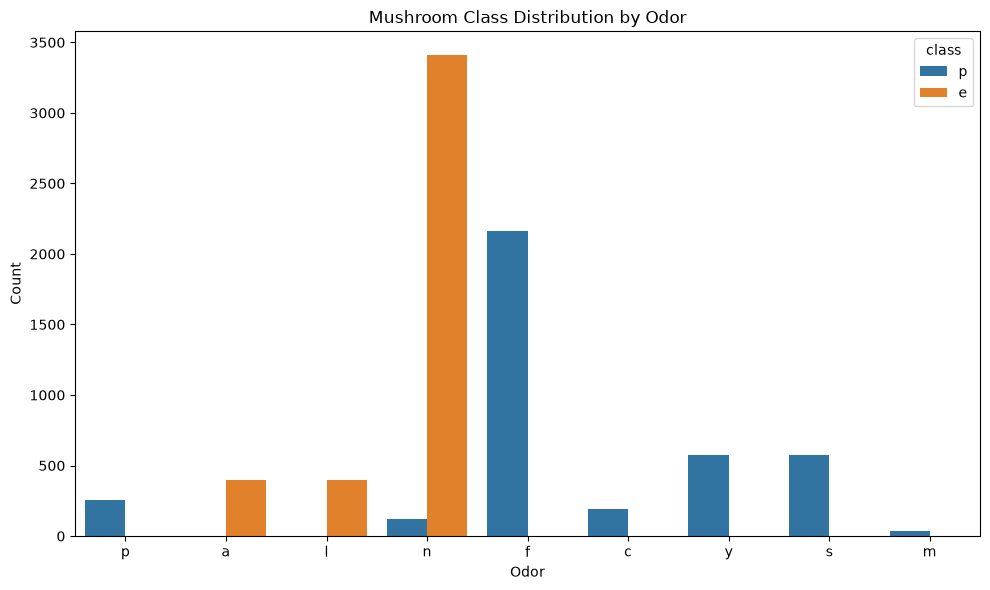

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="odor",
    hue="class"
)

plt.title("Mushroom Class Distribution by Odor")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

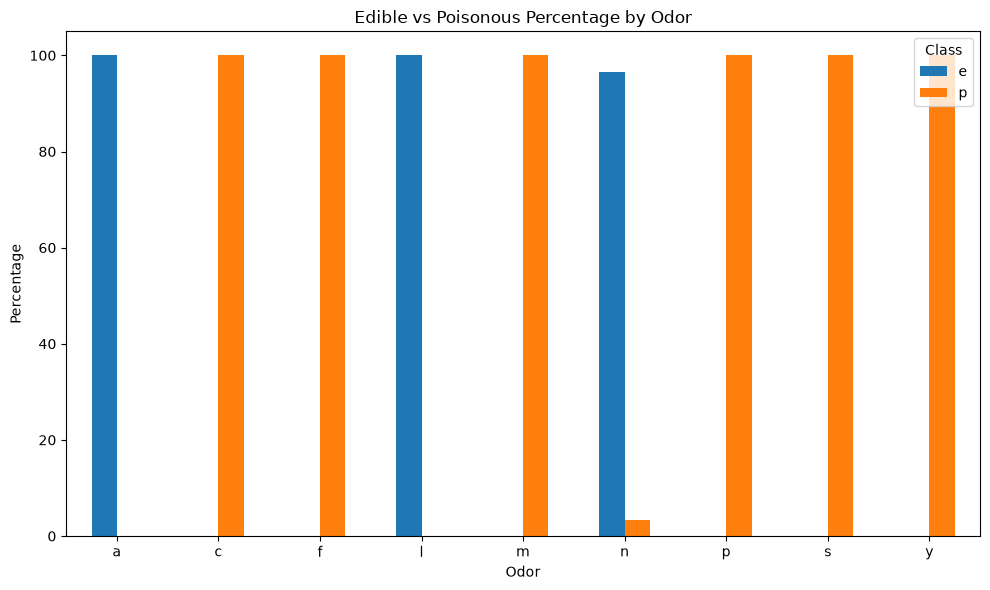

In [19]:
odor_percentage = (
    pd.crosstab(
        df["odor"],
        df["class"],
        normalize="index"
    ) * 100
)

odor_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Edible vs Poisonous Percentage by Odor")
plt.xlabel("Odor")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

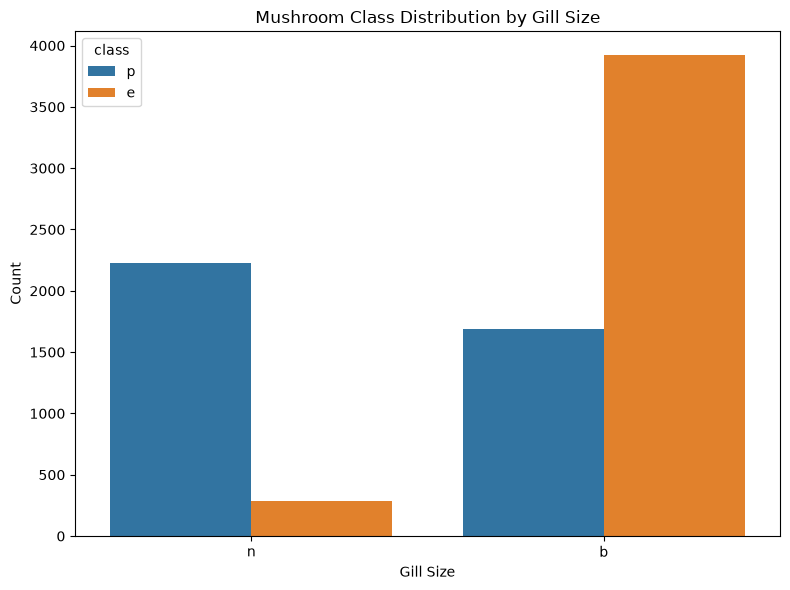

In [20]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="gill-size",
    hue="class"
)

plt.title("Mushroom Class Distribution by Gill Size")
plt.xlabel("Gill Size")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

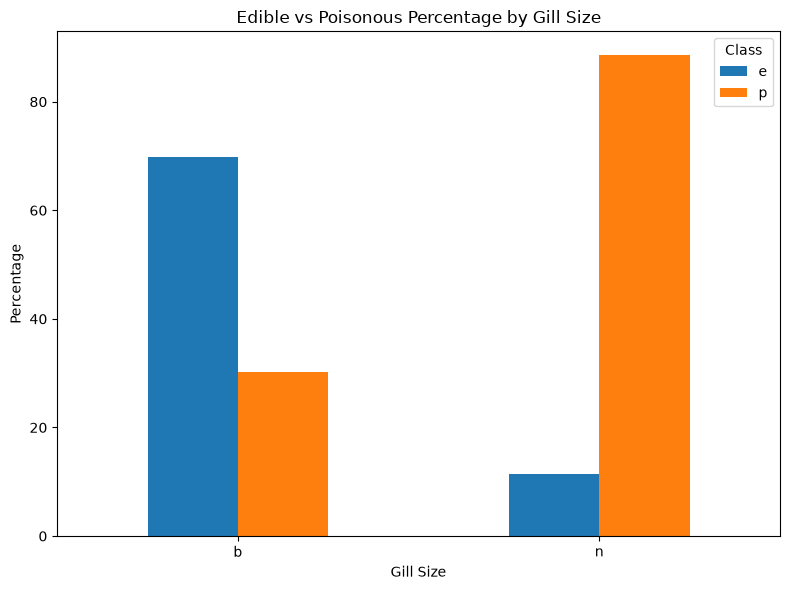

In [21]:
gill_size_percentage = (
    pd.crosstab(
        df["gill-size"],
        df["class"],
        normalize="index"
    ) * 100
)

gill_size_percentage.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Edible vs Poisonous Percentage by Gill Size")
plt.xlabel("Gill Size")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

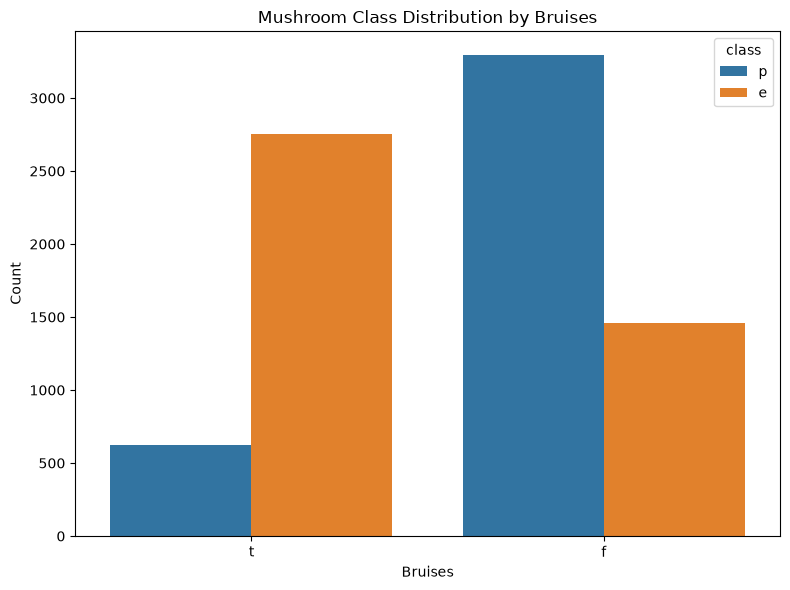

In [22]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="bruises",
    hue="class"
)

plt.title("Mushroom Class Distribution by Bruises")
plt.xlabel("Bruises")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

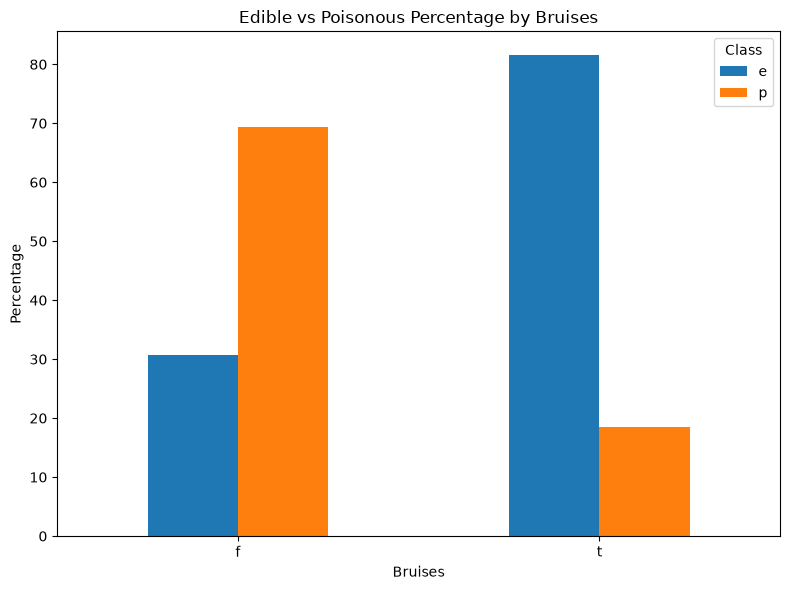

In [23]:
bruises_percentage = (
    pd.crosstab(
        df["bruises"],
        df["class"],
        normalize="index"
    ) * 100
)

bruises_percentage.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Edible vs Poisonous Percentage by Bruises")
plt.xlabel("Bruises")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [24]:
print(df["veil-type"].value_counts())

veil-type
p    8124
Name: count, dtype: int64


In [25]:
print(df["veil-color"].value_counts())

veil-color
w    7924
n      96
o      96
y       8
Name: count, dtype: int64


In [26]:
X = df.drop("class", axis=1)
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8124, 22)
y shape: (8124,)


In [27]:
X = X.drop("veil-type", axis=1)

print("X shape after removing constant feature:", X.shape)

X shape after removing constant feature: (8124, 21)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6499, 21)
X_test: (1625, 21)
y_train: (6499,)
y_test: (1625,)


In [29]:
X_train = X_train.replace("?", "Unknown")
X_test = X_test.replace("?", "Unknown")

In [30]:
print("Unknown in train:", (X_train == "Unknown").sum().sum())
print("Unknown in test:", (X_test == "Unknown").sum().sum())

Unknown in train: 0
Unknown in test: 0


In [31]:
print("Remaining ? in train:", (X_train == "?").sum().sum())
print("Remaining ? in test:", (X_test == "?").sum().sum())

Remaining ? in train: 0
Remaining ? in test: 0


In [32]:
from sklearn.preprocessing import OrdinalEncoder

categorical_features = X_train.columns.tolist()

print(categorical_features)
print("Number of features:", len(categorical_features))

['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Number of features: 21


In [33]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [35]:
import numpy as np

for column in X_train.columns:
    ellipsis_count = X_train[column].apply(lambda x: x is Ellipsis).sum()
    
    if ellipsis_count > 0:
        print(column, ":", ellipsis_count)

stalk-root : 1968


In [36]:
for column in X_train.columns:
    mask = X_train[column].apply(lambda x: x is Ellipsis)
    
    if mask.any():
        print("\nColumn:", column)
        print(X_train.loc[mask, column].head())


Column: stalk-root
5781    Ellipsis
7586    Ellipsis
6181    Ellipsis
7338    Ellipsis
6239    Ellipsis
Name: stalk-root, dtype: object


In [37]:
df = pd.read_csv(destination_path)

print(df.shape)
print(df["stalk-root"].value_counts())

(8124, 23)
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


In [38]:
print(
    df["stalk-root"]
    .map(type)
    .value_counts()
)

stalk-root
<class 'str'>    8124
Name: count, dtype: int64


In [39]:
X = df.drop("class", axis=1)
y = df["class"]

X = X.drop("veil-type", axis=1)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
X_train = X_train.replace("?", "Unknown")
X_test = X_test.replace("?", "Unknown")

In [42]:
for column in X_train.columns:
    ellipsis_count = X_train[column].apply(lambda x: x is Ellipsis).sum()
    
    if ellipsis_count > 0:
        print(column, ":", ellipsis_count)

In [43]:
X = df.drop("class", axis=1)
y = df["class"]

X = X.drop("veil-type", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8124, 21)
y shape: (8124,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6499, 21)
X_test: (1625, 21)


In [45]:
X_train = X_train.replace("?", "Unknown")
X_test = X_test.replace("?", "Unknown")

In [46]:
print("Remaining ? in train:", (X_train == "?").sum().sum())
print("Remaining ? in test:", (X_test == "?").sum().sum())

print("Unknown in train:", (X_train == "Unknown").sum().sum())
print("Unknown in test:", (X_test == "Unknown").sum().sum())

Remaining ? in train: 0
Remaining ? in test: 0
Unknown in train: 1968
Unknown in test: 512


In [47]:
from sklearn.preprocessing import OrdinalEncoder

categorical_features = X_train.columns.tolist()

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (6499, 21)
X_test_encoded shape: (1625, 21)


In [48]:
from sklearn.naive_bayes import CategoricalNB

nb_model = CategoricalNB()

nb_model.fit(X_train_encoded, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U1](2,)","['e','p']"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [49]:
y_pred = nb_model.predict(X_test_encoded)

y_pred_proba = nb_model.predict_proba(X_test_encoded)[:, 1]

In [50]:
print(nb_model.classes_)

['e' 'p']


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="p")
recall = recall_score(y_test, y_pred, pos_label="p")
f1 = f1_score(y_test, y_pred, pos_label="p")
roc_auc = roc_auc_score(
    (y_test == "p").astype(int),
    y_pred_proba
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9458
Precision: 0.9901
Recall   : 0.8966
F1-Score : 0.9410
ROC-AUC  : 0.9972


In [52]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["e", "p"]
)

print(cm)

[[835   7]
 [ 81 702]]


In [53]:
import numpy as np

print("Minimum encoded value:", X_test_encoded.min())
print("Negative values:", np.sum(X_test_encoded < 0))

Minimum encoded value: 0.0
Negative values: 0


In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import CategoricalNB

nb_model = CategoricalNB()

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best alpha:", grid_search.best_params_["alpha"])
print("Best CV ROC-AUC:", grid_search.best_score_)

Best alpha: 0.001
Best CV ROC-AUC: 0.9998449577582488


In [55]:
best_nb_model = CategoricalNB(
    alpha=0.001
)

best_nb_model.fit(
    X_train_encoded,
    y_train
)

y_pred_tuned = best_nb_model.predict(X_test_encoded)

y_pred_proba_tuned = best_nb_model.predict_proba(
    X_test_encoded
)[:, 1]


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    pos_label="p"
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    pos_label="p"
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    pos_label="p"
)

roc_auc_tuned = roc_auc_score(
    (y_test == "p").astype(int),
    y_pred_proba_tuned
)

print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

Accuracy : 0.9908
Precision: 0.9910
Recall   : 0.9898
F1-Score : 0.9904
ROC-AUC  : 0.9996


In [57]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=["e", "p"]
)

print(cm_tuned)

[[835   7]
 [  8 775]]


In [58]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred_tuned

error_analysis["Error_Type"] = "Correct"

error_analysis.loc[
    (error_analysis["Actual"] == "p") &
    (error_analysis["Predicted"] == "e"),
    "Error_Type"
] = "False Negative"

error_analysis.loc[
    (error_analysis["Actual"] == "e") &
    (error_analysis["Predicted"] == "p"),
    "Error_Type"
] = "False Positive"

print(
    error_analysis["Error_Type"].value_counts()
)

Error_Type
Correct           1610
False Negative       8
False Positive       7
Name: count, dtype: int64


In [59]:
false_negatives = error_analysis[
    error_analysis["Error_Type"] == "False Negative"
]

print(false_negatives)

     cap-shape cap-surface cap-color bruises odor gill-attachment  \
5927         b           s         p       t    n               f   
4364         b           y         w       t    n               f   
5423         b           y         b       t    n               f   
5717         k           g         w       t    n               f   
5237         k           y         w       t    n               f   
5617         b           s         w       t    n               f   
4882         b           y         w       t    n               f   
5369         f           s         p       t    n               f   

     gill-spacing gill-size gill-color stalk-shape  ...  \
5927            c         b          g           e  ...   
4364            w         n          w           e  ...   
5423            c         b          g           e  ...   
5717            w         n          w           e  ...   
5237            w         n          w           e  ...   
5617            c       

In [60]:
print(false_negatives["odor"].value_counts())
print(false_negatives["gill-size"].value_counts())
print(false_negatives["bruises"].value_counts())
print(false_negatives["stalk-root"].value_counts())

odor
n    8
Name: count, dtype: int64
gill-size
b    5
n    3
Name: count, dtype: int64
bruises
t    8
Name: count, dtype: int64
stalk-root
b    8
Name: count, dtype: int64


In [61]:
from sklearn.base import BaseEstimator, TransformerMixin

class MushroomPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Replace missing-like values
        X = X.replace("?", "Unknown")

        # Remove constant feature
        X = X.drop("veil-type", axis=1)

        return X

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", MushroomPreprocessor()),

        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),

        ("model", CategoricalNB(
            alpha=0.001
        ))
    ]
)

In [64]:
X = df.drop("class", axis=1)
y = df["class"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
from preprocessing import MushroomPreprocessor

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB


final_pipeline = Pipeline(
    steps=[
        ("preprocessor", MushroomPreprocessor()),

        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),

        ("model", CategoricalNB(
            alpha=0.001
        ))
    ]
)

In [80]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U1](2,)","['e','p']"
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan


In [69]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U1](2,)","['e','p']"
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan


In [81]:
y_pred_pipeline = final_pipeline.predict(X_test)

y_pred_proba_pipeline = final_pipeline.predict_proba(X_test)[:, 1]

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_pipeline)

precision = precision_score(
    y_test,
    y_pred_pipeline,
    pos_label="p"
)

recall = recall_score(
    y_test,
    y_pred_pipeline,
    pos_label="p"
)

f1 = f1_score(
    y_test,
    y_pred_pipeline,
    pos_label="p"
)

roc_auc = roc_auc_score(
    (y_test == "p").astype(int),
    y_pred_proba_pipeline
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9908
Precision: 0.9910
Recall   : 0.9898
F1-Score : 0.9904
ROC-AUC  : 0.9996


In [83]:
cm = confusion_matrix(
    y_test,
    y_pred_pipeline,
    labels=["e", "p"]
)

print(cm)

[[835   7]
 [  8 775]]


In [73]:
import joblib

model_path = "../models/mushroom_categorical_nb_pipeline.pkl"

joblib.dump(
    final_pipeline,
    model_path
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [84]:
loaded_model = joblib.load(model_path)

test_predictions = loaded_model.predict(X_test)

print(test_predictions[:10])

['p' 'p' 'e' 'p' 'p' 'e' 'e' 'e' 'e' 'p']


In [85]:
original_predictions = final_pipeline.predict(X_test)

print(
    "Same predictions:",
    (test_predictions == original_predictions).all()
)

Same predictions: True


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [87]:
X = df.drop("class", axis=1)
y = df["class"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", MushroomPreprocessor()),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),
        ("model", CategoricalNB(alpha=0.001))
    ]
)

In [90]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U1](2,)","['e','p']"
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan


In [91]:
y_pred = final_pipeline.predict(X_test)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="p"))
print("Recall:", recall_score(y_test, y_pred, pos_label="p"))
print("F1-Score:", f1_score(y_test, y_pred, pos_label="p"))
print("ROC-AUC:", roc_auc_score(
    (y_test == "p").astype(int),
    y_pred_proba
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["e", "p"]))

Accuracy: 0.9907692307692307
Precision: 0.9910485933503836
Recall: 0.9897828863346104
F1-Score: 0.9904153354632588
ROC-AUC: 0.9995570966166428

Confusion Matrix:
[[835   7]
 [  8 775]]


In [93]:
import joblib

model_path = "../models/mushroom_categorical_nb_pipeline.pkl"

joblib.dump(
    final_pipeline,
    model_path
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [94]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(X_test)

print(
    "Same predictions:",
    (loaded_predictions == y_pred).all()
)

Same predictions: True
